## First Homework: Linear and Discrete Models (Topics 1,2)

Done by Álvaro Martín and Jaime Salafranca

Deadline for submission: 17th November 2024, 23:59

a) (2 points) Formulate the problem as a linear optimization model (general formulation). Identify the model sets, parameters, variables, objective function and constraints.

b) (3 points) Implement the model in a notebook and solve it for an input based on real ( or realistic) world data. Interpret the solution.

c) (1 point) Compute the sensitivities associated with each constraint , and interpret their values.

d) (4 points) Modify the problem in a) to impose some logical and conditional constraint that require the use of binary or integer variables. The more integer variables or constraints, the better. Implement and solve this new model and interpret the results

The problem must have at least 20 decision variables and 3 non-trivial constraint.

In [124]:
# Import necessary libraries
import pandas as pd
import random
import math
from pyomo.environ import *
from pyomo.opt import SolverFactory
seed = 10
random.seed(seed)

## A) DISCUSSION OF THE PROBLEM AND FORMULATION OF THE LINEAR OPTIMIZATION MODEL:

Nowadays, Formual 1 is facing a big issue when planning the visits of the Great Circus to diferent circuits and countries. Balancing popularity, profitability and environmental issues is an optimization problem that has to be solved by the formula 1 once a year when planning the calendar for next season.

### Problem Description

In this problem, we aim to determine the optimal selection and funding allocation for circuits to host Formula 1 races, ensuring maximum profitability while adhering to various constraints. The goal is to identify the most profitable circuits based on their estimated revenue, costs, and popularity while considering factors such as and budgetary limits. 

The problem involves:
- **Revenue and Cost Estimation**: Estimating potential maximum attendance, ticket prices, and  **maximum costs** for each circuit to calculate profitability.
- **Budget Allocation**: Allocating a limited budget across circuits while adhering to minimum and maximum investment requirements for each circuit.
- **Diversity**: Ensuring a balanced selection of circuits from high, medium, and low popularity categories.

The optimization is formulated as a Linear Programming problem, with the objective of maximizing total profit across all selected circuits while satisfying all constraints. This approach ensures an efficient, fair, and strategic allocation of resources for the Formula 1 championship.

Further details and explanations on the problem will be given over this notebook.

### Mathematical Formulation

The objective of this optimization problem is to allocate funding across Formula 1 circuits to maximize profitability, while adhering to budgetary, diversity, and operational constraints.

---

#### **Decision Variables**

1. **Funding and Selection**:
   - x[i] Continuous variable representing the amount of funding allocated to circuit \( i \).

---

#### **Parameters**

- revenue[i]: Estimated revenue for circuit \( i \).
- cost[i]: Estimated maximum cost for circuit \( i \).
- profit rate[i] = (revenue[i] - cost[i]) / cost[i]: Profit generated per dollar invested in circuit \( i \).
- budget: Total available budget.
- max_allocation[i]: Maximum amount that can be allocated to circuit \( i \). It will be equal to the estimated maximum cost
- min\_investment}[i]: Minimum amount required to fund circuit \( i \).

---

#### **Objective Function**

The objective is to maximize the total profit:
$$
\underset{x, y}{\text{Maximize}} \quad \sum_{i \in \text{circuits}} \text{profit rate}[i] \cdot x[i]
$$

---

#### **Constraints**

### Constraints

In this section, we define constraints to guide the optimization model towards practical and strategic budget allocation decisions:

1. **Total Budget Constraint**:
   $$
   \sum_{\text{loc} \in \text{circuits}} x[\text{loc}] \leq \text{budget}
   $$

2. **Maximum Allocation Constraint**:
   - Limits the amount allocated to each circuit to its maximum allowable allocation (i.e., its estimated maximum cost):
   $$
   x[\text{loc}] \leq \text{max\_allocation}[\text{loc}]
   $$

3. **Category-Specific Minimum Investment Constraints**:
   - These constraints ensure that a minimum amount of the budget is allocated to circuits in each popularity category:
   
   - **High-Popularity Circuits**:
     $$
     \sum_{\text{loc} \in \text{high\_popularity}} x[\text{loc}] \geq 50\,\text{M}
     $$
     - Guarantees at least $50 million USD is invested in high-popularity circuits.
     
   - **Medium-Popularity Circuits**:
     $$
     \sum_{\text{loc} \in \text{medium\_popularity}} x[\text{loc}] \geq 30\,\text{M}
     $$
     - Ensures a minimum investment of $30 million USD in medium-popularity circuits.
     
   - **Low-Popularity Circuits**:
     $$
     \sum_{\text{loc} \in \text{low\_popularity}} x[\text{loc}] \geq 10\,\text{M}
     $$
     - Allocates at least $10 million USD to low-popularity circuits.

These constraints ensure that the budget is not only utilized effectively but also distributed across different categories of circuits to meet strategic goals.

## LOADING THE DATASET AND PREPARING THE DATA     

### Load Datasets
This cell reads the required datasets: `circuits.csv` and `races.csv`. 

In [125]:
# Load datasets
dataset = pd.read_csv("circuits.csv", encoding='latin-1')
dataset_races = pd.read_csv("races.csv", encoding='latin-1')

### Description of the Datasets

#### **1. Circuits Dataset (`circuits.csv`)**
This dataset contains information about Formula 1 circuits. Each row represents a unique circuit. The key columns include:
- **`circuitId`**: A unique identifier for each circuit.
- **`circuitRef`**: A reference name for the circuit.
- **`name`**: The full name of the circuit.
- **`location`**: The city where the circuit is located.
- **`country`**: The country where the circuit is located.
- **`lat`** and **`lng`**: Latitude and longitude of the circuit's location.
- **`alt`**: Altitude of the circuit above sea level (some values are missing).
- **`url`**: A link to the circuit's Wikipedia page.

Example:
| circuitId | circuitRef  | name                             | location      | country     | lat      | lng      | alt  | url                                  |
|-----------|-------------|----------------------------------|---------------|-------------|----------|----------|------|--------------------------------------|
| 1         | albert_park | Albert Park Grand Prix Circuit  | Melbourne     | Australia   | -37.8497 | 144.9680 | 10   | link of the circuit                   |
| 2         | sepang      | Sepang International Circuit    | Kuala Lumpur  | Malaysia    | 2.76083  | 101.7380 | NaN  | link of the circuit                   |

---

#### **2. Races Dataset (`races.csv`)**
This dataset provides information about Formula 1 races. Each row represents a unique race. The key columns include:
- **`raceId`**: A unique identifier for each race.
- **`year`**: The year in which the race occurred.
- **`round`**: The round number in the Formula 1 calendar.
- **`circuitId`**: A foreign key linking the race to a circuit in the `circuits.csv` dataset.
- **`name`**: The name of the race (e.g., "Australian Grand Prix").
- **`date`**: The date of the race.
- **`time`**: The starting time of the race.
- **`url`**: A link to the Wikipedia page for the race.

Example:
| raceId | year | round | circuitId | name                    | date       | time     | url                                  |
|--------|------|-------|-----------|-------------------------|------------|----------|--------------------------------------|
| 1      | 2009 | 1     | 1         | Australian Grand Prix   | 2009-03-29 | 06:00:00 |link of the circuit                   |
| 2      | 2009 | 2     | 2         | Malaysian Grand Prix    | 2009-04-05 | 09:00:00 |link of the circuit                   |

---

#### **Usage in the Project**
1. **Circuits Dataset**:
   - Provides geographical information about circuits, that later will be used in section d) to compute the distances between circuits.

2. **Races Dataset**:
   - Useful for calculating the number of races held at each circuit over the years, which determines their popularity and influences budget allocation decisions in the optimization model, as we will see later.


### Processing the Dataset

The following 3 cells compute the number of races held at each circuit and integrate this information into the `circuits` dataset:

1. **Group and Count Races**:
   - Groups the `races` dataset by `circuitId` to count how many races were held at each circuit over the last years. The races that had been held the most are ssumed to be the most popular ones.
   - Stores the results in a new DataFrame `popularity`, with columns:
     - `circuitId`: Unique identifier for each circuit.
     - `count`: Number of races held at the circuit.

2. **Merge with Circuit Data**:
   - Combines the `popularity` DataFrame with the `circuits` dataset using `circuitId` as the key.
   - Adds the `count` column (race count) to the `circuits` dataset.

3. **Handle Missing Values**:
   - Replaces `NaN` values in the `count` column with `0`. This ensures that circuits with no recorded races are assigned a count of zero. This is a security check and indeed is needed because of the count value for New Jersey Circuit.

4. **Result**:
   - The updated `dataset` contains all circuit details and the number of races held at each circuit.

#### Example:
| circuitId | name                             | location      | country     | count |
|-----------|----------------------------------|---------------|-------------|-------|
| 1         | Albert Park Grand Prix Circuit  | Melbourne     | Australia   | 5     |
| 2         | Sepang International Circuit    | Kuala Lumpur  | Malaysia    | 3     |


The `count` column provides crucial information for determining circuit popularity, which influences further analysis.
Races will be classified in 3 groups given its popularity (high, medium and low popularity). 


In [126]:
# Process the dataset
# Group by circuitId and count the number of races for each circuit
popularity = dataset_races.groupby("circuitId").size().reset_index(name='count')
popularity.columns = ['circuitId', 'count']

In [127]:
# Merge the popularity DataFrame with the dataset
dataset = dataset.merge(popularity, on="circuitId", how="left")

# Replace NaN counts with 0 (for circuits with no races)
dataset['count'] = dataset['count'].fillna(0) 

# Display the resulting DataFrame
dataset.head(5)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url,count
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10.0,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,23.0
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,NaN,http://en.wikipedia.org/wiki/Sepang_Internatio...,19.0
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,NaN,http://en.wikipedia.org/wiki/Bahrain_Internati...,14.0
3,4,catalunya,Circuit de Barcelona-Catalunya,MontmelÌ_,Spain,41.57000,2.26111,NaN,http://en.wikipedia.org/wiki/Circuit_de_Barcel...,28.0
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,NaN,http://en.wikipedia.org/wiki/Istanbul_Park,7.0


In [128]:

# Compute high, medium, and low popularity circuits
sorted_dataset = dataset.sort_values(by='count', ascending=False)
top_9_names = sorted_dataset['name'].head(9).tolist()
next_9_names = sorted_dataset['name'].iloc[9:18].tolist()
remaining_names = sorted_dataset['name'].iloc[18:].tolist()

# Categorize circuits
high_popularity = top_9_names
medium_popularity = next_9_names
low_popularity = remaining_names

### Estimating Attendance, Revenue, and Costs

Now we will estimate the attendance, revenue, and costs for each circuit based on its popularity:

1. **Estimation Function**:
   - Assigns values for attendance, ticket price, and costs based on circuit popularity (high, medium, low).
   - Revenue is calculated as attendance times ticket price.

2. **Update Dataset**:
   - We add three new columns:
     - **`Estimated Attendance`**: Estimated number of attendees.
     - **`Estimated Revenue (USD)`**: Estimated maximum possible revenue in USD.
     - **`Estimated Costs (USD)`**: Estimated maximum costs in USD.



All this provides an approximation of financial and attendance data for each circuit, used in the optimization model.


In [129]:
# Function to estimate attendance, revenue, and costs
def estimate_values(circuit):
    if circuit in high_popularity:
        attendance = random.randint(120000, 140000)
        ticket_price = 350
        costs = random.randint(5000000, 7000000)
    elif circuit in medium_popularity:
        attendance = random.randint(80000, 110000)
        ticket_price = 300
        costs = random.randint(3000000, 5000000)
    else:
        attendance = random.randint(40000, 70000)
        ticket_price = 250
        costs = random.randint(2000000, 4000000)
    
    revenue = attendance * ticket_price
    return attendance, revenue, costs

# Populate DataFrame with calculated values
dataset[["Estimated Attendance", "Estimated Revenue (USD)", "Estimated Costs (USD)"]] = [
    estimate_values(circuit) for circuit in dataset["name"]
]

### Extract Relevant Data

In this section, we extract and preprocess the necessary data to define the parameters of our optimization model:

1. **Extracting Circuit Information**:
   - A subset of the dataset is created containing circuit names, estimated revenues, estimated costs, and popularity counts.

2. **Creating Dictionaries**:
   - `revenue_dict`: Maps each circuit to its estimated maximum possible revenue (if fully funded).
   - `cost_dict`: Maps each circuit to its estimated maximum possible costs.

3. **Computing Profit Rate**:
   - The **profit rate** for each circuit is calculated as:
     $$
     \text{Profit Rate} = \frac{\text{Revenue} - \text{Cost}}{\text{Cost}}
     $$
   - This represents the profit generated per dollar invested in each circuit.
   - This term will be multiplied by the money allocated in the circuit to determine how much profit we have. In this approach, we are assuming that revenues and cost are proportional. That is, if we invest 10$ and get a profit of 2$, if we invested 5 $ in the ciruit we will gain 1$.

4. **Setting the Total Budget**:
   - The total budget for funding circuits is set to **$120 million USD**, which serves as a global constraint for our allocation model.

5. **Defining Maximum Allocation per Circuit**:
   - The cost represents tha maximum that can be invested in a circuit. That is, this is the most we can invest in marketing, facilities, staff... in that circtuit. So it sets a limit on the budget of that cituit. 
   - The **maximum allocation** for each circuit is defined as its cost. We could reduce costs if less money is invested in the circuit, but we cannot spend more than the ***cost*** value in a circuit.

These calculations and constraints form the basis of the optimization model, providing the necessary parameters for decision-making.


In [130]:
# Extract relevant data
d = dataset[['name', 'Estimated Revenue (USD)', 'Estimated Costs (USD)', 'count']]
d.head(5)

,name,Estimated Revenue (USD),Estimated Costs (USD),count
0,Albert Park Grand Prix Circuit,29616900,3068335,23.0
1,Sepang International Circuit,13513250,3012005,19.0
2,Bahrain International Circuit,14735500,2031105,14.0
3,Circuit de Barcelona-Catalunya,26025900,3970101,28.0
4,Istanbul Park,16662500,3030323,7.0


We now have all the exogenous data for this problem, as explained previously some data ae completely real and other data is created to be similar to the real world data.

In [131]:
locations = d["name"].tolist()
revenue_dict = dict(zip(d['name'], d['Estimated Revenue (USD)']))
cost_dict = dict(zip(d['name'], d['Estimated Costs (USD)'])) # maximum cost of the circuit

# Compute profit rate (profit per dollar invested)
profit_rate_dict = {}
for loc in locations:
    revenue = revenue_dict[loc]
    cost = cost_dict[loc]
    profit_rate = (revenue - cost) / cost  # Profit per dollar invested 
    profit_rate_dict[loc] = profit_rate

# Set total budget (in USD)
total_budget = 120e6  # $120 million

# Define maximum allocation per circuit (up to the maximum cost)
max_allocation_dict = cost_dict  # Maximum investment is the maximum cost

## B) IMPLEMENTATION OF THE MODEL IN PYOMO: 

### Define the Optimization Model

This cell sets up the optimization model using Pyomo:

1. **Define the Model**:
   - Creates a `ConcreteModel` instance.

2. **Sets**:
   - `model.circuits`: A set of all circuit names from the `locations` list.

3. **Parameters**:
   - `model.revenue`: Maps each circuit to its estimated revenue.
   - `model.cost`: Maps each circuit to its estimated maximum costs.
   - `model.budget`: The total budget available for allocation.

4. **Variables**:
   - `model.x[loc]`: Continuous variable representing the amount of money allocated to each circuit. It is constrained between 0 and the total budget.
   - `model.y[loc]`: Binary variable indicating whether a circuit receives funding (1 if funded, 0 otherwise).

5. **Objective Function**:
   - **Profit Maximization**: The objective is to maximize the total profit, calculated as the revenue minus costs for each circuit, weighted by the proportion of the allocated budget. 



$$
\text{Profit} = \sum_{\text{loc} \in \text{circuits}} \left( \frac{\text{revenue}(\text{loc}) - \text{cost}(\text{loc})}{\text{cost}(\text{loc})} \times x(\text{loc}) \right)
$$




#### Understanding the Formula

This formula is designed to **spread the budget to maximize total profit**:
- Each circuit has a potential maximum profit if fully funded.
- Partial funding scales the profit proportionally, allowing the budget to be distributed optimally.
- The model focuses on circuits with higher profit margins, ensuring the most efficient use of funds.


1. **What is `revenue(loc) - cost(loc)`?**
This represents the **net profit margin** for the circuit, i.e., how much profit you make if the circuit is fully funded:
- For example, if a circuit generates $10$  $million$ $in$  $revenue$  $and$  $costs$ 6 million, the profit margin is:
  $$
  \text{revenue(loc)} - \text{cost(loc)} = 10 \, \text{million} - 6 \, \text{million} = 4 \, \text{million}
  $$

2. **What is $\frac{x(\text{loc})}{\text{cost}(\text{loc})}$?**
This is the **proportion of the circuit's cost covered by the allocated budget**:
- For instance, if the circuit's cost is 6 million and you allocate 3 millions:
  $$
  \frac{x(\text{loc})}{\text{cost}(\text{loc})} = \frac{3 \, \text{million}}{6 \, \text{million}} = 0.5
  $$
- This means you are funding 50% of the circuit’s operations.

3. **What does the product represent?**
It calculates the **proportional profit**:
$$
(\text{revenue(loc)} - \text{cost(loc)}) \times \frac{x(\text{loc})}{\text{cost}(\text{loc})}
$$

- If fully funding the circuit would result in a 4 million profit, allocating 50% of the cost yields:
  $$
  4 \, \text{million} \times 0.5 = 2 \, \text{million}
  $$




In [132]:
# Define the model
model = ConcreteModel()

# Sets
model.circuits = Set(initialize=locations)

# Parameters
model.profit_rate = Param(model.circuits, initialize=profit_rate_dict)
model.max_allocation = Param(model.circuits, initialize=max_allocation_dict)
model.budget = Param(initialize=total_budget)

# Variables
model.x = Var(model.circuits, domain=NonNegativeReals, bounds=(0, total_budget))


In [133]:
# Objective Function
def profit_rule(model):
    return sum(model.profit_rate[loc] * model.x[loc] for loc in model.circuits)
model.objective = Objective(rule=profit_rule, sense=maximize)


### Constraints already explained in A)

 Athough they are explain at the beggining, let's make a quick review of the constraints we have:
 
We define constraints to guide the optimization model towards practical and strategic budget allocation decisions:

1. **Total Budget Constraint**:
   - Ensures that the total budget allocated across all circuits does not exceed the predefined total budget:
   $$
   \sum_{\text{loc} \in \text{circuits}} x[\text{loc}] \leq \text{budget}
   $$

2. **Maximum Allocation Constraint**:
   - Limits the amount allocated to each circuit to its maximum allowable allocation (i.e., its estimated cost):
   $$
   x[\text{loc}] \leq \text{max\_allocation}[\text{loc}]
   $$
   - This ensures that no circuit receives more funding than required for its projected operations.

3. **Category-Specific Minimum Investment Constraints**:
   - These constraints ensure that a minimum amount of the budget is allocated to circuits in each popularity category:
   
   - **High-Popularity Circuits**:
     $$
     \sum_{\text{loc} \in \text{high\_popularity}} x[\text{loc}] \geq 50\,\text{M}
     $$
     - Guarantees at least $50 million USD is invested in high-popularity circuits.
     
   - **Medium-Popularity Circuits**:
     $$
     \sum_{\text{loc} \in \text{medium\_popularity}} x[\text{loc}] \geq 30\,\text{M}
     $$
     - Ensures a minimum investment of $30 million USD in medium-popularity circuits.
     
   - **Low-Popularity Circuits**:
     $$
     \sum_{\text{loc} \in \text{low\_popularity}} x[\text{loc}] \geq 10\,\text{M}
     $$
     - Allocates at least $10 million USD to low-popularity circuits.



These constraints ensure that the budget is not only utilized effectively but also distributed across different categories of circuits to meet strategic goals.


In [134]:
# NUEVA: nuevo codigo
# Constraints
# Total budget constraint
def budget_constraint_rule(model):
    return sum(model.x[loc] for loc in model.circuits) <= model.budget
model.budget_constraint = Constraint(rule=budget_constraint_rule)

# Max allocation constraints
def max_allocation_rule(model, loc):
    return model.x[loc] <= model.max_allocation[loc]
model.max_allocation_constraints = Constraint(model.circuits, rule=max_allocation_rule)

# Minimum investment in each category of circuits
min_high = 50e6  # At least $50M to high-popularity circuits
min_medium = 30e6  # At least $30M to medium-popularity circuits
min_low = 10e6  # At least $10M to low-popularity circuits

# High-popularity constraint
def min_high_investment_rule(model):
    return sum(model.x[loc] for loc in high_popularity) >= min_high
model.min_high_investment = Constraint(rule=min_high_investment_rule)

# Medium-popularity constraint
def min_medium_investment_rule(model):
    return sum(model.x[loc] for loc in medium_popularity) >= min_medium
model.min_medium_investment = Constraint(rule=min_medium_investment_rule)

# Low-popularity constraint
def min_low_investment_rule(model):
    return sum(model.x[loc] for loc in low_popularity) >= min_low
model.min_low_investment = Constraint(rule=min_low_investment_rule)


### Solution to the problem

In [135]:
# Declare dual suffix for sensitivity analysis
model.dual = Suffix(direction=Suffix.IMPORT)

# Solve the model
solver = SolverFactory('glpk')
result = solver.solve(model, tee=True, suffixes=['dual'])

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\alvar\AppData\Local\Temp\tmp1ga_u_a2.glpk.raw --wglp C:\Users\alvar\AppData\Local\Temp\tmpskpxetd9.glpk.glp
 --cpxlp C:\Users\alvar\AppData\Local\Temp\tmpqnu287ki.pyomo.lp
Reading problem data from 'C:\Users\alvar\AppData\Local\Temp\tmpqnu287ki.pyomo.lp'...
77 rows, 73 columns, 219 non-zeros
605 lines were read
Writing problem data to 'C:\Users\alvar\AppData\Local\Temp\tmpskpxetd9.glpk.glp'...
595 lines were written
GLPK Simplex Optimizer 5.0
77 rows, 73 columns, 219 non-zeros
Preprocessing...
4 rows, 73 columns, 146 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 4
      0: obj =  -0.000000000e+00 inf =   9.000e+07 (3)
     21: obj =   5.755977489e+08 inf =   0.000e+00 (0)
*    42: obj =   7.712527919e+08 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time use

In [136]:
# Another visual way of displaying the results (in a table)

# Prepare data for the table
results = []
for loc in locations:
    allocated_budget = model.x[loc].value
    if allocated_budget > 0:
        percentage = (allocated_budget / total_budget) * 100
        results.append([loc, allocated_budget, percentage])

# Create a DataFrame to display results
results_df = pd.DataFrame(results, columns=["Circuit Name", "Amount Invested", "Percentage of Budget"])
results_df = results_df.sort_values(by="Amount Invested", ascending=False)  # Sort by amount invested

# Print the table
print("\nResults Table:")
# Number of circuits funded
print(f"\nNumber of Circuits Funded: {len(results_df)}")
results_df.head(len(results_df))



Results Table:

Number of Circuits Funded: 33


,Circuit Name,Amount Invested,Percentage of Budget
6,Hockenheimring,6997325.0,5.831104
10,AutÌ_dromo JosÌ© Carlos Pace,6438355.0,5.365296
3,Circuit de Monaco,6370431.0,5.308693
8,Circuit de Spa-Francorchamps,6264982.0,5.220818
9,Autodromo Nazionale di Monza,5800285.0,4.833571
11,NÌ_rburgring,5278875.0,4.399062
5,Silverstone Circuit,5159570.0,4.299642
7,Hungaroring,5093441.0,4.244534
4,Circuit Gilles Villeneuve,5072149.0,4.226791
18,Kyalami,4883654.0,4.069712


## **Results Overview and Conclusions**

The optimization model successfully allocated the \$120 million budget across **33** Formula 1 circuits to maximize total profit while adhering to the defined constraints. Below are the key observations from the results:

### **1. Budget Allocation**
- **Total Budget Utilization:** The model efficiently utilized the entire budget, ensuring that funds were optimally distributed without exceeding the \$120 million limit.
- **Highest Investments:** Circuits such as **Hockenheimring**, **Autodromo Jose Carlos Pace**, and **Circuit de Monaco** received the highest allocations (\$6,997,325; \$6,438,355; and \$6,370,431 respectively), indicating their strong profitability and strategic importance.

### **2. Profit Maximization**
- **Profit-Oriented Funding:** The allocation strategy prioritized circuits with higher profit rates. This is evident from the substantial investments in circuits that offer greater returns on investment.
- **Balanced Distribution:** Funds were distributed across various popularity categories—high, medium, and low—ensuring a diversified investment portfolio that mitigates risk and capitalizes on different market segments.

### **3. Number of Circuits Funded**
- **Optimal Selection:** Funding this **33** circuits is the optimal soution to maximize the porfit while fulfilling hte constraints.


## **Conclusions**

The optimization model effectively achieves its objective of maximizing profitability within the \$120 million budget while adhering to investment and popularity constraints. Key takeaways include:

- **Strategic Funding:** By prioritizing circuits with higher profit rates and ensuring balanced investments across popularity categories, the model supports sustainable financial growth and market expansion.
  
- **Balanced Portfolio:** Funding a substantial number of circuits across various categories and locations mitigates risks and leverages diverse revenue streams, enhancing the overall stability and profitability of the Formula 1 championship.


## C) COMPUTE THE SENSITIVITIES ASSOCIATED WITH EACH CONSTRAINT:

In [137]:
# Display dual values (sensitivities)
print("\nDual Values (Sensitivities) Associated with Each Constraint:\n")

# Dual for budget constraint
dual_budget = model.dual.get(model.budget_constraint, None)
if dual_budget is not None:
    print(f"Budget Constraint Dual Value: {dual_budget:.4f}")
else:
    print("Budget Constraint Dual Value: Not available")
dual_values = {}
# Duals for max allocation constraints
print("\nDuals for Max Allocation Constraints:")
for loc in locations:
    constraint = model.max_allocation_constraints[loc]
    dual_value = model.dual.get(constraint, None)
    if dual_value is not None:
        dual_values[loc] = dual_value
        print(f"Max Allocation Constraint for {loc}: Dual = {dual_value:.4f}")
    else:
        print(f"Max Allocation Constraint for {loc}: Dual not available")


Dual Values (Sensitivities) Associated with Each Constraint:

Budget Constraint Dual Value: 4.7972

Duals for Max Allocation Constraints:
Max Allocation Constraint for Albert Park Grand Prix Circuit: Dual = 3.8552
Max Allocation Constraint for Sepang International Circuit: Dual = 0.0000
Max Allocation Constraint for Bahrain International Circuit: Dual = 1.4577
Max Allocation Constraint for Circuit de Barcelona-Catalunya: Dual = 0.7583
Max Allocation Constraint for Istanbul Park: Dual = 0.0000
Max Allocation Constraint for Circuit de Monaco: Dual = 1.2953
Max Allocation Constraint for Circuit Gilles Villeneuve: Dual = 2.8456
Max Allocation Constraint for Circuit de Nevers Magny-Cours: Dual = 0.0000
Max Allocation Constraint for Silverstone Circuit: Dual = 3.0716
Max Allocation Constraint for Hockenheimring: Dual = 0.6148
Max Allocation Constraint for Hungaroring: Dual = 3.2619
Max Allocation Constraint for Valencia Street Circuit: Dual = 0.0000
Max Allocation Constraint for Circuit de 

# Explanation of Dual Values (Sensitivities) Associated with Constraints


## 1. Budget Constraint Dual Value
The **budget constraint dual value** measures the marginal benefit of increasing the budget by one unit. 

- **Value:** 4.6
 For every additional unit of budget, the objective  profit will increase by approximately 4.67 units, provided the current allocation is optimal.

---

## 2. Max Allocation Constraints

### Non-Zero Dual Values
Locations with non-zero dual values are those where the maximum allocation constraint is active or binding. This means additional allocation capacity at these locations would improve the objective function. For example:
- **Silverstone Circuit (2.3484):** Increasing the maximum allocation would increase the objective by approximately 2.35 units per additional unit of capacity.
- **Circuit Park Zandvoort (3.1476):** This location has the highest sensitivity, suggesting the greatest potential improvement in the objective if the maximum allocation is increased.

### Zero Dual Values
For locations with zero dual values (e.g., **Sepang International Circuit, Bahrain International Circuit**), the constraint is not active, meaning the current allocation is below the maximum allowed, and increasing the maximum would not affect the objective function.

---

## Key Observations

   - Locations such as **Circuit Park Zandvoort** and **Yas Marina Circuit** are significant contributors to the objective function, making them high-priority targets for resource allocation.


   - Locations like **Sepang International Circuit** and **Bahrain International Circuit** have excess capacity, suggesting no immediate benefit from increasing their maximum allocation.

   - The budget constraint dual value of 4.6713 indicates a high return on increasing the budget, which could justify re-evaluating the total budget allocation.




In [138]:
# Create DataFrame for the dual values (sensitivities)
dual_df = pd.DataFrame(list(dual_values.items()), columns=["Circuit", "Dual Value"])

# Convert the "Dual Value" column to numeric, setting errors='coerce' to handle non-numeric values
dual_df["Dual Value"] = pd.to_numeric(dual_df["Dual Value"], errors="coerce")

# Sorting the DataFrame for top 10 biggest and zeroed dual values
top_10_biggest = dual_df.sort_values(by="Dual Value", ascending=False).head(10)
top_10_zeroed = dual_df[dual_df["Dual Value"] == 0].head(10)

# Display the tables
print("Top 10 Biggest Dual Values:")
top_10_biggest

Top 10 Biggest Dual Values:


,Circuit,Dual Value
24,AutÌ_dromo Juan y Oscar GÌÁlvez,4.084881
0,Albert Park Grand Prix Circuit,3.855227
21,Suzuka Circuit,3.470198
10,Hungaroring,3.261876
8,Silverstone Circuit,3.071556
19,NÌ_rburgring,2.946768
6,Circuit Gilles Villeneuve,2.845580
38,Circuit Park Zandvoort,2.219695
13,Autodromo Nazionale di Monza,2.145895
44,Jarama,2.040055


In [139]:

print("\nTop 10 Zeroed Dual Values:")
top_10_zeroed



Top 10 Zeroed Dual Values:


,Circuit,Dual Value
1,Sepang International Circuit,0.0
4,Istanbul Park,0.0
7,Circuit de Nevers Magny-Cours,0.0
11,Valencia Street Circuit,0.0
14,Marina Bay Street Circuit,0.0
15,Fuji Speedway,0.0
16,Shanghai International Circuit,0.0
18,Indianapolis Motor Speedway,0.0
25,Circuito de Jerez,0.0
26,AutÌ_dromo do Estoril,0.0


## D) MODIFY PROBLEM AND IMPOSE LOGICAL CONDITIONS AND CONSTRAINTS THAT REQUIERE BINARY/INTEGER VARIABLES

The data in this part remains the same than in previous one. 

We will include more constraints and a binary variable for this part.

The first change is that tow, there will be not only maximum, but also **minimum**  investment constraints

In [140]:
# Set total budget (in USD)
total_budget = 120e6  # $120 million

# Define maximum allocation per circuit (up to the estimated cost)
max_allocation_dict = cost_dict  # Maximum investment is the estimated cost

# Define minimum investment per circuit (50% of the maximum estimated cost)
min_investment_dict = {loc: 0.5 * cost_dict[loc] for loc in locations}


### Binary Variables (model.y) 
The new ***model.y*** Represents funding decisions for each circuit (1 if funded, 0 otherwise). It will be useful to define some of the new constraints as we will see later.

In [141]:
# Define the model
model = ConcreteModel()

# Sets
model.circuits = Set(initialize=locations)
model.circuit_pairs = Set(initialize=[(i, j) for i in locations for j in locations if i != j])

# Parameters
model.profit_rate = Param(model.circuits, initialize=profit_rate_dict)
model.max_allocation = Param(model.circuits, initialize=max_allocation_dict)
model.min_investment = Param(model.circuits, initialize=min_investment_dict)
model.budget = Param(initialize=total_budget)

# Variables
# x[loc]: amount of money allocated to circuit 'loc'
model.x = Var(model.circuits, domain=NonNegativeReals)
# y[loc]: binary variable indicating whether circuit 'loc' is funded
model.y = Var(model.circuits, domain=Binary)
model.routes = Var(model.circuit_pairs, domain=Binary)

### Distance-Based Constraints

1. **Haversine
Formula**:
- It is used
to
calculate
the
distance
between
two
points
on
the
Earth
given
their
latitude and longitude.Thiss
formula
takes
into
account
the
curvature
of
the
Earth
when
computing
the
distances.In
the
problem, it is used
to
compute
the
distance
between
all
pairs
of
circuits:
$$
\text
{distance} = 2 \cdot
R \cdot \arctan2\left(\sqrt
{a}, \sqrt
{
    1 - a}\right),  \quad a = \sin ^ 2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1) \cdot \cos(\phi_2) \cdot \sin ^ 2\left(\frac{\Delta \ lambda}{2}\right)
$$
where:
- $R$ is Earth
's radius (6371 km),
- $\phi_1$, $\phi_2$ are latitudes,
- $\lambda_1$, $\lambda_2$ are longitudes.

2. **Distance
Matrix**:
- For
each
pair
of
circuits, the
computed
Haversine
distance is stored in a
matrix, which is used
to
evaluate
whether
circuits
are
too
close.

3. **Minimum
Distance
Constraint**:
- Ensures
that
no
two
circuits
closer
than
a
specified
threshold(`min_distance_km = 500
km
`) are
funded
simultaneously.This
constraint
prevents
allocating
resources
to
circuits
that
are
geographically
too
close
to
each
other:
$$
y[\text
{loc1}] + y[\text
{loc2}] \leq
1, \quad \forall(\text
{loc1}, \text
{loc2}) \text
{
with } \text{distance}(\text{loc1},  \text{loc2}) < 500 \,  \text{km}
$$

4. **Implementation**:
- A
list
of
close
circuit
pairs is generated
based
on
the
distance
matrix and the
minimum
distance
threshold.
- A
constraint is added for each pair to ensure mutual exclusivity in funding.


In [142]:

# Distance-Based Constraints
# Function to calculate distance using the Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = phi2 - phi1
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi / 2.0) ** 2 + \
        math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2.0) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c  # in kilometers
    return distance


# Get latitudes and longitudes
location_coords = dict()
for loc in locations:
    lat, lon = dataset.loc[dataset["name"] == loc, ["lat", "lng"]].values[0]
    location_coords[loc] = (lat, lon)

# Compute the distance matrix
distance_matrix = {}
for loc1 in locations:
    distance_matrix[loc1] = {}
    for loc2 in locations:
        lat1, lon1 = location_coords[loc1]
        lat2, lon2 = location_coords[loc2]
        distance = haversine_distance(lat1, lon1, lat2, lon2)
        distance_matrix[loc1][loc2] = distance  # in kilometers
        

We create a distance parameter that stores the distances of all possible combinations between circuits.

In [143]:
model.distance = Param(
    model.circuit_pairs,
    initialize={(i, j): distance_matrix[i][j] for i, j in model.circuit_pairs},
    default=0,
)
# Define minimum distance
min_distance_km = 500  # Minimum distance in kilometers between funded circuits
cost_per_km= 1

Now our model takes also into account the distance between circuits. The cost of travelling from one circuit to the next will be take into account in the objective fucntion, and we will  also **restrict that the circuits are too close** (we don't want to have races in circuits that are too close to each other).

The profit rule can be expressed as:

$$
\text{Profit} = \sum_{\text{loc} \in \text{model.circuits}} \left( \text{model.profit\_rate}[\text{loc}] \times \text{model.x}[\text{loc}] \right)
$$

$$
\text{Travel Cost} = \sum_{(i, j) \in \text{model.circuit\_pairs}} \left( \text{model.routes}[i, j] \times \text{model.distance}[i, j] \times \text{cost\_per\_km} \right)
$$

Thus, the total profit is:

$$
\text{Total Profit} = \text{Profit} - \text{Travel Cost}
$$





In [144]:

# Objective Function
def profit_rule(model):
    profit = sum(model.profit_rate[loc] * model.x[loc] for loc in model.circuits)
    travel_cost = sum(
        model.routes[i, j] * model.distance[i, j] * cost_per_km for i, j in model.circuit_pairs
    )
    return profit - travel_cost
model.objective = Objective(rule=profit_rule, sense=maximize)

### Firsts Constraints

1. **Total Budget Constraint**:
   Ensures that the total budget allocated across all circuits does not exceed the predefined total budget:
   $$
   \sum_{\text{loc} \in \text{circuits}} x[\text{loc}] \leq \text{budget}
   $$

2. **Max Allocation Constraint**:
   Limits the amount allocated to each circuit to its maximum allowable allocation (`max_allocation`). A circuit can only receive funding if it is selected (`y[loc] = 1`):
   $$
   x[\text{loc}] \leq y[\text{loc}] \cdot \text{max\_allocation}[\text{loc}]
   $$

3. **Min Investment Constraint**:
   Ensures that if a circuit is selected (`y[loc] = 1`), it receives at least its minimum required investment (`min_investment`):
   $$
   x[\text{loc}] \geq y[\text{loc}] \cdot \text{min\_investment}[\text{loc}]
   $$

These constraints ensure that the budget is utilized effectively while adhering to investment limits for each circuit.


In [145]:
# Constraints
# Total budget constraint
def budget_constraint_rule(model):
    return sum(model.x[loc] for loc in model.circuits) <= model.budget
model.budget_constraint = Constraint(rule=budget_constraint_rule)

# Max allocation constraints
def max_allocation_rule(model, loc):
    return model.x[loc] <= model.y[loc] * model.max_allocation[loc]
model.max_allocation_constraints = Constraint(model.circuits, rule=max_allocation_rule)

# Min investment constraints
def min_investment_rule(model, loc):
    return model.x[loc] >= model.y[loc] * model.min_investment[loc]
model.min_investment_constraints = Constraint(model.circuits, rule=min_investment_rule)


### Conditional Constraints

1. **High-Medium Dependency Constraint**: Ensures that if a high-popularity circuit is funded (`y[h] = 1`), then at least two medium-popularity circuits must also be funded. This promotes balance in the allocation of resources across different popularity levels:
   $$
   y[h] \leq \frac{1}{2} (\sum_{m \in \text{medium\_popularity}} y[m]), \quad \forall h \in \text{high\_popularity}
   $$

2. **Medium-Low Dependency Constraint**: Ensures that if a medium-popularity circuit is funded (`y[m] = 1`), then at least one low-popularity circuit must also be funded. This encourages support for less popular circuits:
   $$
   y[m] \leq \sum_{l \in \text{low\_popularity}} y[l], \quad \forall m \in \text{medium\_popularity}
   $$

3. **Minimum High-Popularity Circuits Constraint**: Enforces that at least `k_high` high-popularity circuits must be funded. This guarantees a minimum level of support for the most popular circuits:
   $$
   \sum_{h \in \text{high\_popularity}} y[h] \geq k_{\text{high}}
   $$

4. **Total Circuits Funded Constraint**: Restricts the total number of circuits funded to be between `N_min` and `N_max`. This maintains a controlled range of selected circuits:
   $$
   N_{\text{min}} \leq \sum_{loc \in \text{circuits}} y[loc] \leq N_{\text{max}}
   $$


In [146]:
# Conditional Constraints

# 1. If a high-popularity circuit is funded, then at least two medium-popularity circuits must also be funded
def high_medium_dependency_rule(model, h):
    return model.y[h] <= (1/2) * sum(model.y[m] for m in medium_popularity)
model.high_medium_dependency = Constraint(high_popularity, rule=high_medium_dependency_rule)

# 2. If a medium-popularity circuit is funded, at least one low-popularity circuit must also be funded
def medium_low_dependency_rule(model, m):
    return model.y[m] <= sum(model.y[l] for l in low_popularity)
model.medium_low_dependency = Constraint(medium_popularity, rule=medium_low_dependency_rule)

# 3. At least k_high high-popularity circuits must be funded
k_high = 3
def min_high_circuits_rule(model):
    return sum(model.y[h] for h in high_popularity) >= k_high
model.min_high_circuits = Constraint(rule=min_high_circuits_rule)

# 4. Total number of circuits funded must be between N_min and N_max
N_min = 15
N_max = 25
def total_circuits_rule(model):
    return inequality(N_min, sum(model.y[loc] for loc in model.circuits), N_max)
model.total_circuits_constraint = Constraint(rule=total_circuits_rule)



### Distance and routing Constraints and Formulas

#### 1. **Close Pairs Constraint**
The model ensures that two locations, which are within a certain minimum distance (`min_distance_km`), cannot both be funded. If two locations are considered a "close pair," at most one of them can be selected for funding.

**Formula**:

$$
y_{\text{loc1}} + y_{\text{loc2}} \leq 1
$$

Where:
- $y_{\text{loc1}}$ and $y_{\text{loc2}}$ are binary decision variables indicating whether location 1 and location 2 are funded (1 if funded, 0 if not).
- This constraint ensures that if $ y_{\text{loc1}} = 1 $, then $ y_{\text{loc2}} = 0 $, and vice versa.

#### 2. **Flow Constraints**
To ensure valid routing, if a location is selected for funding, it must have corresponding routes to and from other locations. The flow constraints enforce that the sum of outgoing and incoming routes must match the funding decision for each location.

**Flow Out Constraint** (for each location):

$$
\sum_{j \neq \text{loc}} \text{routes}(\text{loc}, j) = y_{\text{loc}}
$$

Where:
-  routes represents the decision variable for the route from location loc to location j.
- y_loc is the binary variable indicating whether location loc is funded.

**Flow In Constraint** (for each location (loc) ):

$$
\sum_{i \neq \text{loc}} \text{routes}(i, \text{loc}) = y_{\text{loc}}
$$

Where:
- $\text{routes}(i, \text{loc}) $ represents the decision variable for the route from location $i $ to location $ \text{loc} $.

These constraints ensure that the location's funding decision is consistent with the route assignments.




In [147]:
close_pairs = []
for loc1 in locations:
    for loc2 in locations:
        if loc1 != loc2 and distance_matrix[loc1][loc2] < min_distance_km:
            if (loc2, loc1) not in close_pairs:
                close_pairs.append((loc1, loc2))


def min_distance_rule(model, loc1, loc2):
    return model.y[loc1] + model.y[loc2] <= 1


model.min_distance_constraints = ConstraintList()
for loc1, loc2 in close_pairs:
    model.min_distance_constraints.add(min_distance_rule(model, loc1, loc2))


def flow_out_constraint(model, loc):
    return sum(model.routes[loc, j] for j in model.circuits if loc != j) == model.y[loc]


def flow_in_constraint(model, loc):
    return sum(model.routes[i, loc] for i in model.circuits if loc != i) == model.y[loc]


model.flow_out = Constraint(model.circuits, rule=flow_out_constraint)
model.flow_in = Constraint(model.circuits, rule=flow_in_constraint)


### Solution of the problem

In [148]:
model.dual = Suffix(direction=Suffix.IMPORT_EXPORT)

# Solve the model
solver = SolverFactory('glpk')
result = solver.solve(model, tee=True)

print("\nObjective (Total Profit): ${:,.2f}".format(model.objective()))

funded_circuits = []
for loc in locations:
    allocated_budget = model.x[loc].value
    if allocated_budget > 0:
        funded_circuits.append(loc)
        print(f"Circuit: {loc}")
        print(f"  Funded: Yes")
        print(f"  Allocated Budget: ${allocated_budget:,.2f}")
        print(f"  Estimated Revenue: ${revenue_dict[loc]:,.2f}")
        print(f"  Estimated Cost: ${cost_dict[loc]:,.2f}")
        profit = model.profit_rate[loc] * allocated_budget
        print(f"  Profit: ${profit:,.2f}\n")
    else:
        print(f"Circuit: {loc}")
        print(f"  Funded: No\n")

# Print funded circuits
print(f"\nNumber of Circuits Funded: {len(funded_circuits)}")
print("Funded Circuits:", funded_circuits)


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\alvar\AppData\Local\Temp\tmpt56n506m.glpk.raw --wglp C:\Users\alvar\AppData\Local\Temp\tmpbtoy6_0v.glpk.glp
 --cpxlp C:\Users\alvar\AppData\Local\Temp\tmpdjowioqd.pyomo.lp
Reading problem data from 'C:\Users\alvar\AppData\Local\Temp\tmpdjowioqd.pyomo.lp'...
C:\Users\alvar\AppData\Local\Temp\tmpdjowioqd.pyomo.lp:24283: warning: lower bound of variable 'x75' redefined
C:\Users\alvar\AppData\Local\Temp\tmpdjowioqd.pyomo.lp:24283: warning: upper bound of variable 'x75' redefined
480 rows, 5402 columns, 12104 non-zeros
5329 integer variables, all of which are binary
29612 lines were read
Writing problem data to 'C:\Users\alvar\AppData\Local\Temp\tmpbtoy6_0v.glpk.glp'...
23723 lines were written
GLPK Integer Optimizer 5.0
480 rows, 5402 columns, 12104 non-zeros
5329 integer variables, all of which are binary
Preprocessing...
9 hidden covering inequaliti(es) were detected
480 rows, 5402 columns, 12104

In [149]:
selected_circuits = [loc for loc in locations if model.y[loc].value == 1]
travel_route = [(i, j) for i, j in model.circuit_pairs if model.routes[i, j].value == 1]

## CONCLUSION 


We are going to plot the chosen circuits and chosen routes. We will observe some sub-routes that are allowed in our constraints. This makes our problem linear but not ideal for real life. Creating a constraint that creates one route would grow the problem exponentially and we will see that in other chapters, that is why we stopped here our research. Avoiding this problem would require of teh SalesMan Problem.

In [150]:
# pip install basemap # unocomment if needed
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import networkx as nx
import plotly.graph_objects as go


circuits = selected_circuits
travel_routes = travel_route
filtered_dataset = dataset[dataset['name'].isin(circuits)]

circuit_coords = dict(zip(
    filtered_dataset['name'],
    zip(filtered_dataset['lat'], filtered_dataset['lng'])
))

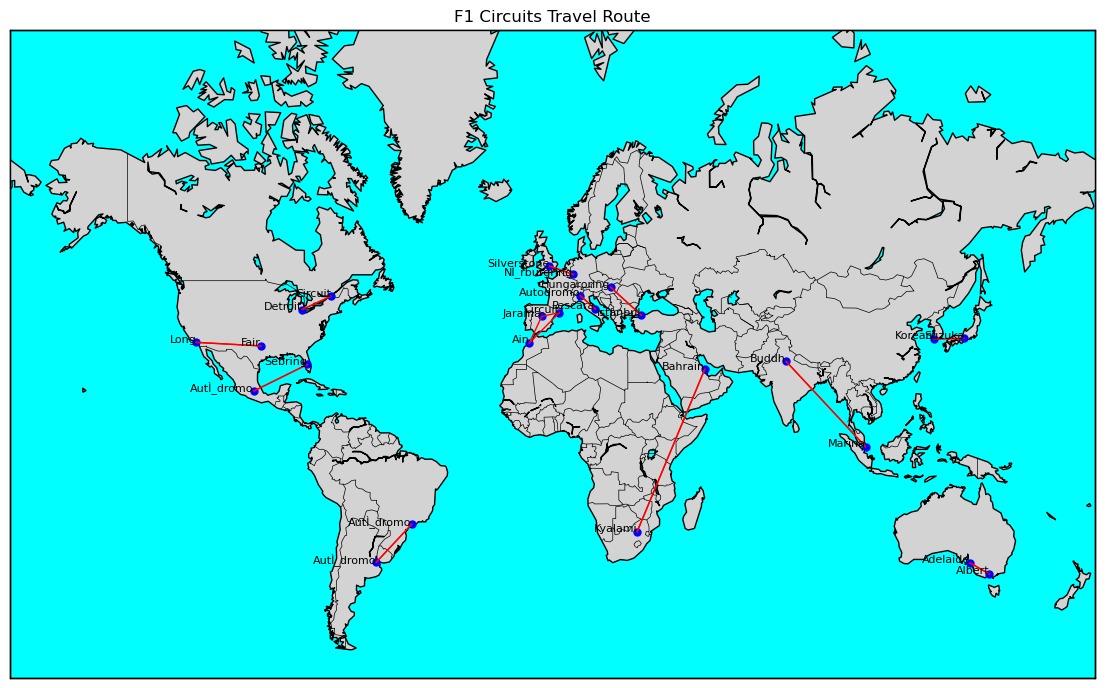

In [151]:

plt.figure(figsize=(14, 10))
m = Basemap(projection='merc', llcrnrlat=-60, urcrnrlat=80, llcrnrlon=-180, urcrnrlon=180, resolution='c')

m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray', lake_color='aqua')
m.drawmapboundary(fill_color='aqua')

for circuit, (lat, lon) in circuit_coords.items():
    x, y = m(lon, lat)
    plt.plot(x, y, 'bo', markersize=5)
    plt.text(x, y, circuit.split()[0], fontsize=8, ha='right')

for start, end in travel_route:
    start_lat, start_lon = circuit_coords[start]
    end_lat, end_lon = circuit_coords[end]
    x1, y1 = m(start_lon, start_lat)
    x2, y2 = m(end_lon, end_lat)
    plt.plot([x1, x2], [y1, y2], 'r-', lw=1)

plt.title('F1 Circuits Travel Route')
plt.show()

In [152]:

fig = go.Figure()
for circuit, (lat, lon) in circuit_coords.items():
    fig.add_trace(go.Scattergeo(
        lon=[lon],
        lat=[lat],
        text=circuit,
        mode='markers+text',
        marker=dict(size=8, color='blue'),
        textfont=dict(size=10),  # Smaller text size
        textposition="top center",
    ))

for start, end in travel_route:
    start_lat, start_lon = circuit_coords[start]
    end_lat, end_lon = circuit_coords[end]
    fig.add_trace(go.Scattergeo(
        lon=[start_lon, end_lon],
        lat=[start_lat, end_lat],
        mode='lines',
        line=dict(width=2, color='red'),
        hoverinfo='none'
    ))
fig.update_layout(
    title='F1 Circuits Travel Route',
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor="rgb(230, 230, 230)",
        showocean=True,
        oceancolor="rgb(180, 220, 255)",
        showcountries=True,
        countrycolor="rgb(200, 200, 200)",
        resolution=50
    )
)
fig.show()